In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("insurance2.csv")

In [ ]:
df_encoded = pd.read_csv("insurance2.csv")

In [ ]:

# Sex
df['sex'] = df['sex'].replace({
    0: 'Female',
    1: 'Male'
})

# Smoker
df['smoker'] = df['smoker'].replace({
    0: 'Not Smoking',
    1: 'Smoking'
})

# Region
df['region'] = df['region'].replace({
    0: 'Northeast',
    1: 'Northwest',
    2: 'Southeast',
    3: 'Southwest'
})

# Insurance Claim
df['insuranceclaim'] = df['insuranceclaim'].replace({
    0: 'No Claim',
    1: 'Claim'
})

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,Female,27.900,0,Smoking,Southwest,16884.92400,Claim
1,18,Male,33.770,1,Not Smoking,Southeast,1725.55230,Claim
2,28,Male,33.000,3,Not Smoking,Southeast,4449.46200,No Claim
3,33,Male,22.705,0,Not Smoking,Northwest,21984.47061,No Claim
4,32,Male,28.880,0,Not Smoking,Northwest,3866.85520,Claim


In [ ]:
df.shape

(1338, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 83.8+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0
insuranceclaim,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

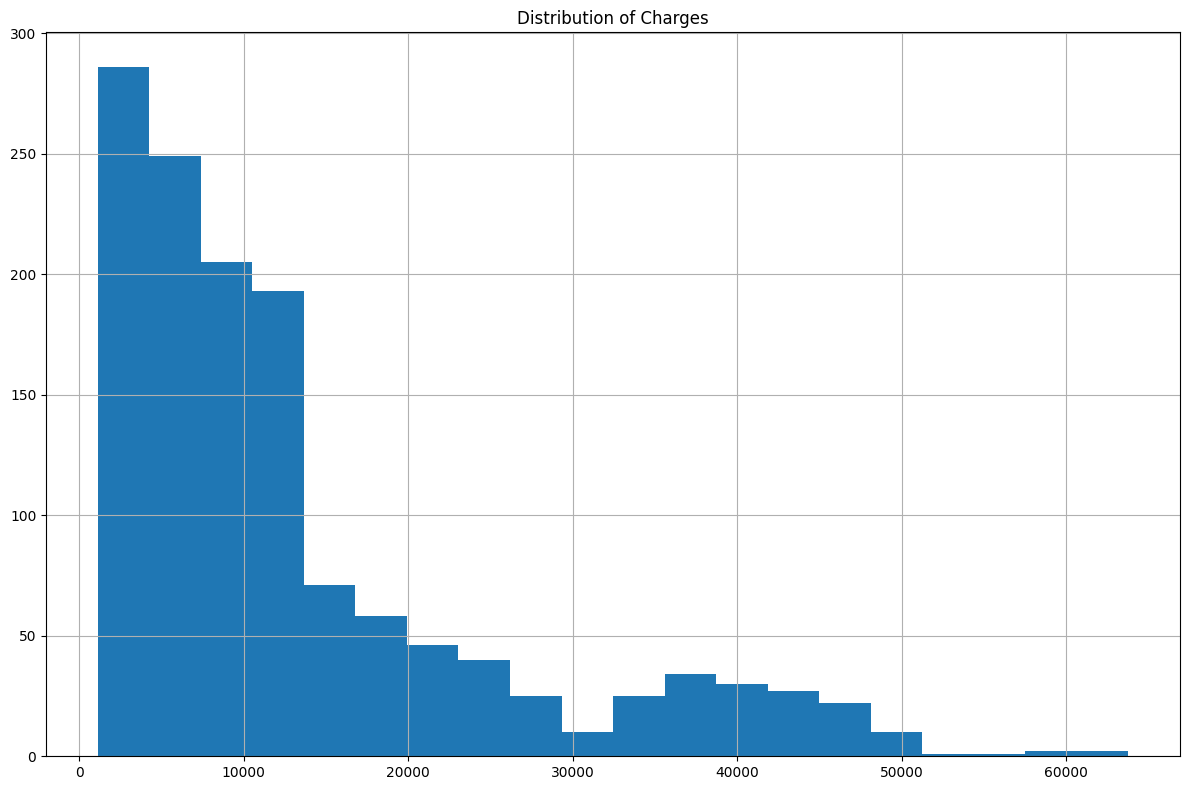

In [ ]:
df['charges'].hist(bins=20)

plt.gcf().set_size_inches(12, 8)
plt.title('Distribution of Charges')
plt.tight_layout()
plt.show()

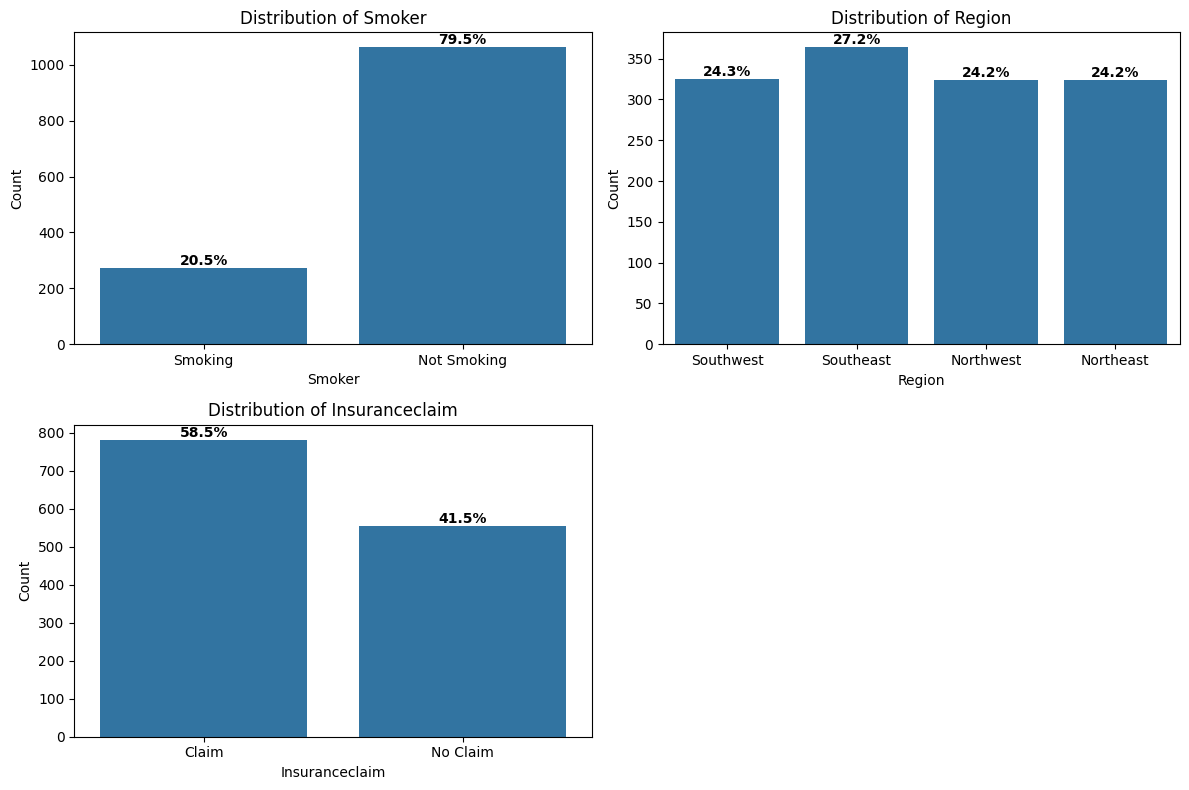

In [ ]:
categorical_cols = [ 'smoker', 'region', 'insuranceclaim']

plt.figure(figsize=(12,8))

for i, col in enumerate(categorical_cols):

    plt.subplot(2,2,i+1)

    ax = sns.countplot(x=df[col])

    # Total observations
    total = len(df[col])

    # Add percentage labels
    for p in ax.patches:

        percentage = 100 * p.get_height() / total

        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

    plt.title(f'Distribution of {col.capitalize()}')

    plt.ylabel('Count')
    plt.xlabel(col.capitalize())

plt.tight_layout()
plt.show()

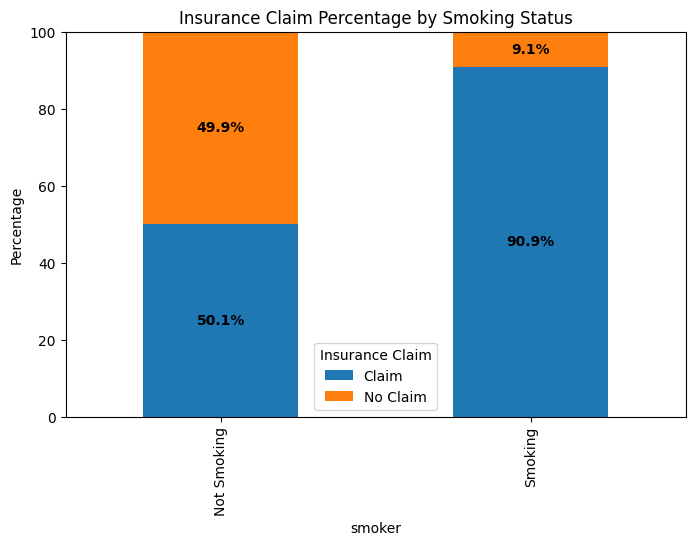

In [ ]:
smoker_claim = pd.crosstab(
    df['smoker'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = smoker_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

# Add percentage labels
for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Smoking Status')

plt.ylabel('Percentage')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

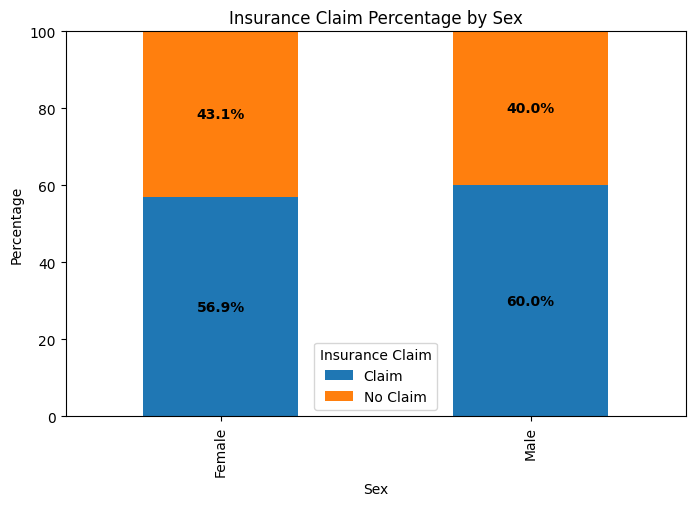

In [ ]:
sex_claim = pd.crosstab(
    df['sex'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = sex_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Sex')

plt.ylabel('Percentage')

plt.xlabel('Sex')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

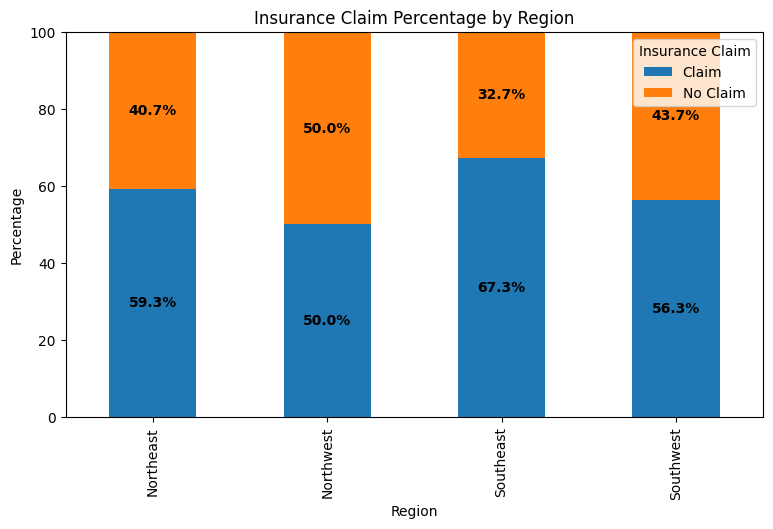

In [ ]:
region_claim = pd.crosstab(
    df['region'],
    df['insuranceclaim'],
    normalize='index'
) * 100

ax = region_claim.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

for container in ax.containers:

    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.title('Insurance Claim Percentage by Region')

plt.ylabel('Percentage')

plt.xlabel('Region')

plt.ylim(0,100)

plt.legend(title='Insurance Claim')

plt.show()

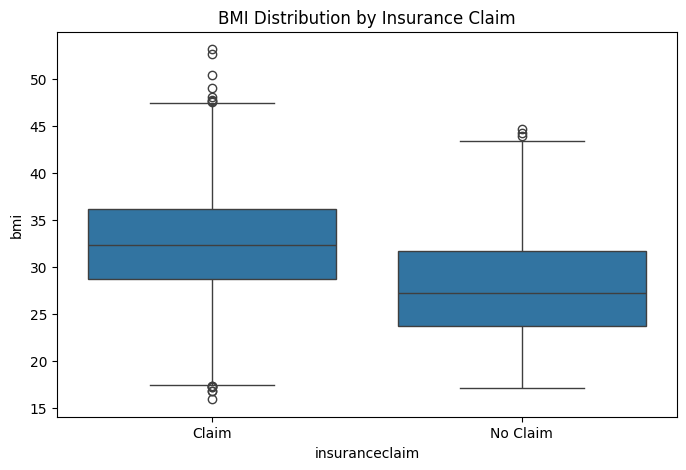

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='insuranceclaim',
    y='bmi',
    data=df
)

plt.title('BMI Distribution by Insurance Claim')

plt.show()

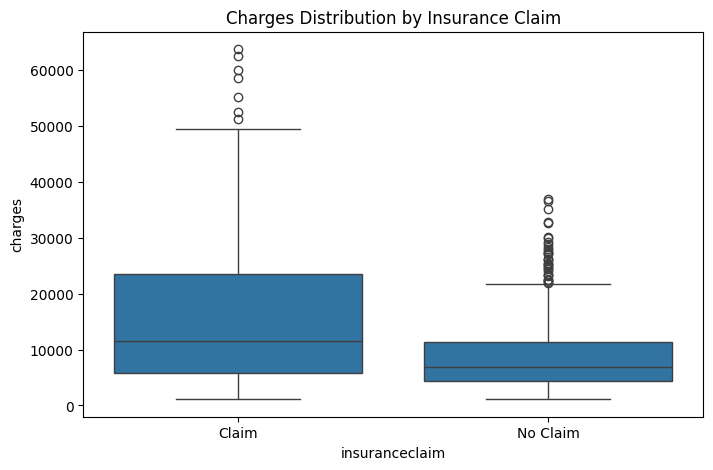

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='insuranceclaim',
    y='charges',
    data=df
)

plt.title('Charges Distribution by Insurance Claim')

plt.show()

In [ ]:
from scipy.stats import shapiro

claim_yes_bmi = df_encoded[df_encoded['insuranceclaim'] == 1]['bmi']

claim_no_bmi = df_encoded[df_encoded['insuranceclaim'] == 0]['bmi']

print(shapiro(claim_yes_bmi))
print(shapiro(claim_no_bmi))

ShapiroResult(statistic=np.float64(0.9922949446132323), pvalue=np.float64(0.0004344171803840097))
ShapiroResult(statistic=np.float64(0.9729179897238167), pvalue=np.float64(1.3243309383861967e-08))


In [ ]:
from scipy.stats import shapiro

claim_yes_charges = df_encoded[df_encoded['insuranceclaim'] == 1]['charges']

claim_no_charges = df_encoded[df_encoded['insuranceclaim'] == 0]['charges']

print(shapiro(claim_yes_charges))
print(shapiro(claim_no_charges))

ShapiroResult(statistic=np.float64(0.8645576502937047), pvalue=np.float64(1.9416759156866585e-25))
ShapiroResult(statistic=np.float64(0.8494858545169038), pvalue=np.float64(1.428062393188244e-22))


In [ ]:
from scipy.stats import shapiro

claim_yes_age = df_encoded[df_encoded['insuranceclaim'] == 1]['age']

claim_no_age = df_encoded[df_encoded['insuranceclaim'] == 0]['age']

print(shapiro(claim_yes_age))
print(shapiro(claim_no_age))

ShapiroResult(statistic=np.float64(0.927382330090049), pvalue=np.float64(5.274987021450468e-19))
ShapiroResult(statistic=np.float64(0.9573930554046155), pvalue=np.float64(1.3917488295377508e-11))


In [ ]:
from scipy.stats import shapiro

claim_yes = df_encoded[df_encoded['insuranceclaim'] == 1]['children']

claim_no = df_encoded[df_encoded['insuranceclaim'] == 0]['children']

print(shapiro(claim_yes))
print(shapiro(claim_no))

ShapiroResult(statistic=np.float64(0.7140001359139532), pvalue=np.float64(1.769576032727527e-34))
ShapiroResult(statistic=np.float64(0.9102271853384702), pvalue=np.float64(1.3662293113690904e-17))


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_bmi,
    claim_no_bmi
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 318602.0
P-value: 5.831855158138455e-48


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_age,
    claim_no_age
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 245138.5
P-value: 6.294707075537323e-05


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes_charges,
    claim_no_charges
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 282433.0
P-value: 8.286037438810306e-21


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    claim_yes,
    claim_no
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 114645.0
P-value: 1.822079115703687e-54


## Global Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # Import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Define features (X) and target (y) using the deduplicated 'df'
# 'df' comes from 37dfd005, where 'sex' and 'smoker' are boolean and 'region' is int64
X = df.drop('insuranceclaim', axis=1).copy() # Ensure copy
y = df['insuranceclaim'] # Target is already numerical 0/1

# Identify features for different encoding strategies
ordinal_features = ['sex', 'smoker']
onehot_features = ['region']
numerical_features = ['age', 'bmi', 'children', 'charges']

# Get unique categories for one-hot encoded features (region is int64 in X)
region_categories = sorted(X['region'].unique()) # e.g., [0, 1, 2, 3]

# Create preprocessing transformers
numerical_transformer = StandardScaler()
# OrdinalEncoder for boolean features (sex, smoker). It will map False -> 0, True -> 1 (or vice versa depending on sort).
ordinal_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
# OneHotEncoder for integer region feature. Explicit categories ensure consistency.
onehot_transformer = OneHotEncoder(
    handle_unknown='ignore',
    drop=None,
    categories=[region_categories] # Explicitly define categories for region (e.g., [0, 1, 2, 3])
)

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('ohe', onehot_transformer, onehot_features)
    ],
    remainder='passthrough' # Keep any other columns if they exist
)

# Create a pipeline with preprocessing and a Gradient Boosting Classifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', GradientBoostingClassifier(random_state=42))])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model_pipeline.fit(X_train, y_train)

# Store y_prob for the global GradientBoosting model for later use in cell 3ede7563
y_prob_global_gbc = model_pipeline.predict_proba(X_test)[:, 1]

print("Global model trained successfully with updated encoding strategy (Ordinal for sex/smoker, OneHot for region)!")

Global model trained successfully with updated encoding strategy (Ordinal for sex/smoker, OneHot for region)!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class (claim)

# Evaluate the model
print("### Model Evaluation (Global Model) ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, pos_label='Claim'):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred, labels=['No Claim', 'Claim']), index=['Actual No Claim', 'Actual Claim'], columns=['Predicted No Claim', 'Predicted Claim']))


print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=['No Claim', 'Claim']))

### Model Evaluation (Global Model) ###
Accuracy: 0.9888
Precision: 0.9936
Recall: 0.9873
F1-Score: 0.9904
ROC AUC Score: 0.9961

Confusion Matrix:


,Predicted No Claim,Predicted Claim
Actual No Claim,110,1
Actual Claim,2,155



Classification Report:
              precision    recall  f1-score   support

    No Claim       0.98      0.99      0.99       111
       Claim       0.99      0.99      0.99       157

    accuracy                           0.99       268
   macro avg       0.99      0.99      0.99       268
weighted avg       0.99      0.99      0.99       268



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier # Added KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier # Explicitly import, though already in a539ad73

# Initialize models
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
knn_model = KNeighborsClassifier() # Replaced XGBoost with KNeighborsClassifier
svm_model = SVC(random_state=42, probability=True) # probability=True for ROC AUC score

# Dictionary to store new models
additional_global_models = {
    'Logistic Regression': logistic_model,
    'KNeighbors': knn_model, # Changed model name
    'SVM': svm_model
}

# Dictionary to store metrics for new models
additional_global_metrics = {}

# Iterate through and train/evaluate each new model
for model_name, model in additional_global_models.items():
    print(f"\n--- Training and Evaluating Global {model_name} Model ---")

    # Create a pipeline with preprocessing and the current model
    model_pipeline_new = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', model)])

    # Train the model (y_train is now numerical 0/1)
    model_pipeline_new.fit(X_train, y_train)

    # Make predictions
    y_pred_new = model_pipeline_new.predict(X_test)
    y_prob_new = model_pipeline_new.predict_proba(X_test)[:, 1]

    y_train_pred_new = model_pipeline_new.predict(X_train)

    # Calculate metrics (y_test and predictions are numerical 0/1)
    accuracy_test = accuracy_score(y_test, y_pred_new)
    accuracy_train = accuracy_score(y_train, y_train_pred_new)
    precision = precision_score(y_test, y_pred_new, pos_label='Claim')
    recall = recall_score(y_test, y_pred_new, pos_label='Claim')
    f1 = f1_score(y_test, y_pred_new, pos_label='Claim')
    roc_auc = roc_auc_score(y_test, y_prob_new)

    additional_global_metrics[model_name] = {
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc
    }

    print(f"Training Accuracy: {accuracy_train:.4f}")
    print(f"Testing Accuracy: {accuracy_test:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")

print("\n--- Consolidated Global Model Performance Comparison ---")

# Recalculate global_metrics to include training accuracy for GradientBoosting
# model_pipeline (GradientBoosting) was trained with numerical y_train in a539ad73
predictions_train_gbc = model_pipeline.predict(X_train)
y_pred_gbc = model_pipeline.predict(X_test)

global_metrics_gbc = {
    'accuracy_train': accuracy_score(y_train, predictions_train_gbc),
    'accuracy_test': accuracy_score(y_test, y_pred_gbc),
    'precision': precision_score(y_test, y_pred_gbc, pos_label='Claim'),
    'recall': recall_score(y_test, y_pred_gbc, pos_label='Claim'),
    'f1_score': f1_score(y_test, y_pred_gbc, pos_label='Claim'),
    'roc_auc_score': roc_auc_score(y_test, y_prob_global_gbc) # Use y_prob from cell a539ad73
}

# Combine all global model metrics
all_global_models_metrics = {
    'GradientBoosting (Global)': global_metrics_gbc # Changed model name
}
all_global_models_metrics.update(additional_global_metrics)

consolidated_comparison_df = pd.DataFrame.from_dict(all_global_models_metrics, orient='index')

display(consolidated_comparison_df.round(4))


--- Training and Evaluating Global Logistic Regression Model ---
Training Accuracy: 0.8793
Testing Accuracy: 0.8657
Precision: 0.8623
Recall: 0.9172
F1-Score: 0.8889
ROC AUC Score: 0.9204

--- Training and Evaluating Global KNeighbors Model ---
Training Accuracy: 0.9289
Testing Accuracy: 0.8806
Precision: 0.9032
Recall: 0.8917
F1-Score: 0.8974
ROC AUC Score: 0.9436

--- Training and Evaluating Global SVM Model ---
Training Accuracy: 0.9205
Testing Accuracy: 0.9067
Precision: 0.9342
Recall: 0.9045
F1-Score: 0.9191
ROC AUC Score: 0.9540

--- Consolidated Global Model Performance Comparison ---


,accuracy_train,accuracy_test,precision,recall,f1_score,roc_auc_score
GradientBoosting (Global),0.9944,0.9888,0.9936,0.9873,0.9904,0.9961
Logistic Regression,0.8793,0.8657,0.8623,0.9172,0.8889,0.9204
KNeighbors,0.9289,0.8806,0.9032,0.8917,0.8974,0.9436
SVM,0.9205,0.9067,0.9342,0.9045,0.9191,0.9540
